In [2]:
from pathlib import Path
from typing import Tuple

import numpy as np
import tensorflow as tf
from huggingface_hub import snapshot_download

from app.services.preprocessing import image_bytes_to_tf_string_tensor


class DermFoundationBackbone:
    """
    Thin wrapper around the Google Derm Foundation SavedModel.
    It converts image bytes into the model's serialized tf.Example input
    and returns the 6144-d embedding.
    """

    def __init__(
        self,
        repo_id: str = "google/derm-foundation",
        token: str | None = None,
        local_files_only: bool = False,
        image_size: int = 448,
    ) -> None:
        self.repo_id = repo_id
        self.image_size: Tuple[int, int] = (image_size, image_size)

        model_path = snapshot_download(
            repo_id=repo_id,
            token=token,
            local_files_only=local_files_only,
        )
        self.model_path = Path(model_path)
        self.model = tf.saved_model.load(str(self.model_path))
        self.infer = self.model.signatures["serving_default"]

    def image_to_embedding(self, image_bytes: bytes) -> np.ndarray:
        """
        Return embedding with shape [1, embedding_dim].
        Derm Foundation normally returns key: "embedding".
        """
        tf_inputs = image_bytes_to_tf_string_tensor(image_bytes, img_size=self.image_size)

        # Your notebook used infer(inputs=tf_inputs). Keep that first.
        try:
            output = self.infer(inputs=tf_inputs)
        except TypeError:
            output = self.infer(tf_inputs)

        if "embedding" not in output:
            available = ", ".join(output.keys())
            raise KeyError(f"Expected output key 'embedding'. Available keys: {available}")

        return output["embedding"].numpy().astype("float32")


HF_TOKEN found.


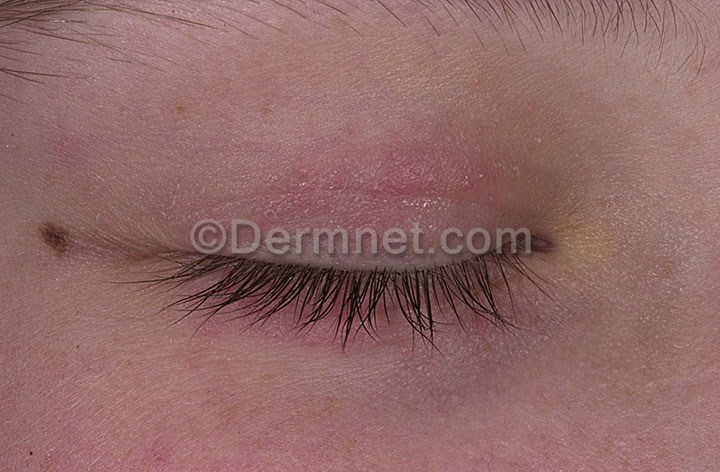

Image size: (720, 472)


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Backbone loaded in 1.84 seconds
Model path: /Users/danielhuynh/.cache/huggingface/hub/models--google--derm-foundation/snapshots/a16a6ab4f87888948fe248136e697ed28146a1c6


I0000 00:00:1778741900.513001  297328 service.cc:153] XLA service 0x114aac050 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778741900.513109  297328 service.cc:161]   StreamExecutor [0]: Host, Default Version (Driver: 0.0.0; Runtime: 0.0.0; Toolkit: 0.0.0; DNN: 0.0.0)
I0000 00:00:1778741900.735797  297328 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778741901.327202  297328 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Embedding extracted in 2.06 seconds
Embedding type: <class 'numpy.ndarray'>
Embedding dtype: float32
Embedding shape: (1, 6144)
Feature extraction test passed.


In [3]:
from pathlib import Path
import os
import time

from dotenv import load_dotenv
from PIL import Image

# ----------------------------
# Load Hugging Face token
# ----------------------------

load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")

if HF_TOKEN is None:
    print("Warning: HF_TOKEN not found in .env or environment variables.")
    print("If the model is already cached locally, this may still work.")
else:
    print("HF_TOKEN found.")


# ----------------------------
# Pick test image
# ----------------------------

# Change this filename to your actual test image name
test_image_path = Path("07PerioralDermEye.jpg")

assert test_image_path.exists(), f"Image not found: {test_image_path}"

# Optional visual sanity check
img = Image.open(test_image_path).convert("RGB")
display(img)
print("Image size:", img.size)


# ----------------------------
# Load Derm Foundation backbone
# ----------------------------

t0 = time.perf_counter()

backbone = DermFoundationBackbone(
    repo_id="google/derm-foundation",
    token=HF_TOKEN,
    local_files_only=False,
    image_size=448,
)

t1 = time.perf_counter()

print(f"Backbone loaded in {t1 - t0:.2f} seconds")
print("Model path:", backbone.model_path)


# ----------------------------
# Extract embedding
# ----------------------------

image_bytes = test_image_path.read_bytes()

t2 = time.perf_counter()

embedding = backbone.image_to_embedding(image_bytes)

t3 = time.perf_counter()

print(f"Embedding extracted in {t3 - t2:.2f} seconds")
print("Embedding type:", type(embedding))
print("Embedding dtype:", embedding.dtype)
print("Embedding shape:", embedding.shape)


# ----------------------------
# Basic checks
# ----------------------------

assert embedding.ndim == 2, f"Expected 2D embedding, got shape {embedding.shape}"
assert embedding.shape[0] == 1, f"Expected batch size 1, got shape {embedding.shape}"
assert embedding.shape[1] == 6144, f"Expected embedding dim 6144, got shape {embedding.shape}"

print("Feature extraction test passed.")